In [32]:
from pathlib import Path
import scipy.io as sio
import pandas as pd
import numpy as np
import matplotlib as plt
import pursuit_functions
import pyarrow as pa

pd.set_option('display.max_columns', 100)  # Show more columns (default is 20)

%load_ext autoreload
%autoreload 2

# TODO: 
# * normalize column names (i.e. sessFile -> dataDir)
# * look into LP03_03_pursuitRoot.mat corruption

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:


def optimize_pyarrow_dtypes(df):
    """
    Optimizes PyArrow-backed dtypes in a DataFrame by selecting the smallest appropriate dtype
    for each column based on value ranges.
    
    Parameters:
        df (pd.DataFrame): A DataFrame with PyArrow-backed dtypes.

    Returns:
        pd.DataFrame: A DataFrame with optimized PyArrow-backed dtypes.
    """
    optimized_dtypes = {}

    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            min_val, max_val = df[col].min(), df[col].max()

            # Select the most efficient integer dtype
            if min_val >= 0 and max_val <= 255:
                optimized_dtypes[col] = pd.ArrowDtype(pa.uint8())
            elif min_val >= 0 and max_val <= 65535:
                optimized_dtypes[col] = pd.ArrowDtype(pa.uint16())
            elif min_val >= -128 and max_val <= 127:
                optimized_dtypes[col] = pd.ArrowDtype(pa.int8())
            elif min_val >= -32768 and max_val <= 32767:
                optimized_dtypes[col] = pd.ArrowDtype(pa.int16())
            elif min_val >= -(2**31) and max_val <= (2**31 - 1):
                optimized_dtypes[col] = pd.ArrowDtype(pa.int32())
            else:
                optimized_dtypes[col] = pd.ArrowDtype(pa.int64())

        elif pd.api.types.is_float_dtype(df[col]):
            min_val, max_val = df[col].min(), df[col].max()

            # Select the most efficient float dtype
            if min_val >= -65504 and max_val <= 65504:
                optimized_dtypes[col] = pd.ArrowDtype(pa.float16())
            elif min_val >= -(2**31) and max_val <= (2**31 - 1):
                optimized_dtypes[col] = pd.ArrowDtype(pa.float32())
            else:
                optimized_dtypes[col] = pd.ArrowDtype(pa.float64())

    # Convert DataFrame dtypes
    return df.astype(optimized_dtypes)



In [34]:
#load region files
data_dir = Path("/Users/may/pursuitSessionFiles")
#data_dir = Path("/Volumes/ASA_Lab/Data/Xiaoxiao/ppcRscEVCPoster/pursuitSessionFiles")
region_directories = pursuit_functions.file_reader.load_region_files(data_dir, 'SL.mat')
print("Extracted structures:", region_directories.keys())

Loading: /Users/may/pursuitSessionFiles/ca3SL.mat
Loading: /Users/may/pursuitSessionFiles/ca1SL.mat
Loading: /Users/may/pursuitSessionFiles/rscSL.mat
Extracted structures: dict_keys(['ca3SL', 'ca1SL', 'rscSL'])


/Users/may/miniconda/envs/pursuit_project/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [35]:
#load pursuit files
data_dir = Path("/Users/may/pursuitSessionFiles")
#data_dir = Path("/Volumes/ASA_Lab/Data/Xiaoxiao/ppcRscEVCPoster/pursuitSessionFiles")

pursuit_session_files = pursuit_functions.file_reader.load_session_files(data_dir)

Loading: /Users/may/pursuitSessionFiles/KB20_12_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_07_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB10_20_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP06_30_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP03_20_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB09_23_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP06_29_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP03_04_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/LP06_14_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB10_04_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_23_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB09_40_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB20_04_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_08_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/KB19_35_pursuitRoot.mat
Loading: /Users/may/pursuitSessionFiles/

In [36]:
#set a variable to a region_directories file
ca1_directory = pd.DataFrame(region_directories['ca1SL'])
ca3_directory = pd.DataFrame(region_directories['ca3SL'])
rsc_directory = pd.DataFrame(region_directories['rscSL'])

#display first few rows of the dataframe
ca1_directory.head()
ca3_directory.head()
rsc_directory.head()

,sessFile,tt,cellIndex,spkTimes,recNum,bsFile,blocks,frFile,muRate,peakRate,burstIndexBlocks,smFile,smRm,recHemi
0,KB10_02_pursuitRoot.mat,17,1,"[0.1669, 0.28305, 0.380875, 0.751525, 0.764025...",22,KB10_02_BS_tt17c1.mat,"[[88504.0, 144672.0], [8320.0, 86109.0], [nan,...",KB10_02_frAnalysis_tt17c1.mat,"(4.692906611241162, array([4.81011602, 4.03313...","(16.519418703312862, array([18.17084393, 15.20...","[[0.00422892585283338, 0.007944915254237288, n...",KB10_02_selfMotion_tt17c1.mat,"(array([[[4.63917526, 4.63917526, nan],...",1
1,KB10_02_pursuitRoot.mat,25,2,"[0.137075, 1.542725, 1.817975, 1.9046, 1.9853,...",22,KB10_02_BS_tt25c2.mat,"[[88504.0, 144672.0], [8320.0, 86109.0], [nan,...",KB10_02_frAnalysis_tt25c2.mat,"(2.9235510103222015, array([2.63846026, 2.8036...","(10.614618064280595, array([10.20781357, 10.99...","[[0.028413575374901343, 0.029219143576826197, ...",KB10_02_selfMotion_tt25c2.mat,"(array([[[2.4742268 , 3.09278351, nan],...",1
2,KB10_03_pursuitRoot.mat,17,1,"[0.31265, 0.40455, 0.445, 0.4775, 0.518525, 0....",23,KB10_03_BS_tt17c1.mat,"[[96666.0, 150971.0], [7012.0, 95499.0], [nan,...",KB10_03_frAnalysis_tt17c1.mat,"(8.021706903089898, array([6.45894457, 8.41191...","(22.749134609044773, array([20.92174844, 23.74...","[[0.007995202878273036, 0.014315111389460499, ...",KB10_03_selfMotion_tt17c1.mat,"(array([[[ 7.83289817, 8.77284595, na...",1
3,KB10_08_pursuitRoot.mat,17,2,"[0.00245, 0.26885, 0.33075, 0.362575, 0.393025...",28,KB10_08_BS_tt17c2.mat,"[[71396.0, 129658.0], [3303.0, 68617.0], [nan,...",KB10_08_frAnalysis_tt17c2.mat,"(12.618480565373458, array([11.3938197 , 12.81...","(27.7547058072976, array([26.3693488 , 28.0684...","[[0.003832151753209427, 0.0035780842340663436,...",KB10_08_selfMotion_tt17c2.mat,"(array([[[ 8.80989181, 12.42658423, na...",1
4,KB10_09_pursuitRoot.mat,17,2,"[0.951425, 1.18095, 1.861625, 1.908275, 2.6613...",29,KB10_09_BS_tt17c2.mat,"[[80670.0, 170910.0], [6153.0, 73687.0], [nan,...",KB10_09_frAnalysis_tt17c2.mat,"(5.106691507714666, array([5.99589072, 3.70028...","(18.579987410995223, array([20.95010962, 13.91...","[[0.06509289006844532, 0.040225563909774435, n...",KB10_09_selfMotion_tt17c2.mat,"(array([[[4.4516129 , 3. , nan],...",1


In [37]:
#convert extracted pursuit session data into dataframes
pursuit_df = {
    filename: pd.DataFrame(file_data).convert_dtypes(dtype_backend="pyarrow")
    for filename, file_data in pursuit_session_files.items()
}

#display first few rows of a dataframe for a specific pursuit file
pursuit_df['KB20_09_pursuitRoot.mat'].head()

,time,ind,ratPos_1,ratPos_2,laserPos_1,laserPos_2,ratVel,ratAcc,laserVel,laserAcc,ratMoveDir,laserMoveDir,ratHeadDir,ratAV,laserAV,laserDist,laserBearingMD,laserBearingHD,centerDist,centerBearingMD,centerBearingHD,spkTable_1,spkTable_2,spkTable_3,spkTable_4,spkTable_5,spkTable_6,spkTable_7,spkTable_8,spkTable_9,spkTable_10
0,0.016667,1,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,-2.033685,0.714289,<NA>,<NA>,0.004366,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,0,0,0,0,0,0,0
1,0.033334,2,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,-2.08084,0.718656,<NA>,0.047155,0.00074,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,0,0,0,0,0,0,0
2,0.050001,3,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,-2.126666,0.719396,<NA>,0.045827,0.000309,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,0,0,0,0,0,0,0
3,0.066668,4,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,-2.17155,0.719705,<NA>,0.044883,0.000172,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,0,0,0,0,0,1,0
4,0.083335,5,<NA>,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,-2.21625,0.719877,<NA>,0.0447,0.000112,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,0,0,0,0,0,0,0,0,0


In [38]:
#extract trial block indices for all 3 region directory dataframes

def extract_trial_blocks(region_directory):
    """Extracts start and end indices for trial blocks and stores them as separate columns."""

    #ensure column names are clean
    region_directory.columns = region_directory.columns.str.strip()

    #determine the correct block column structure
    has_blocks = "blocks" in region_directory.columns
    has_separate_blocks = all(col in region_directory.columns for col in ["feBlock", "pursuitBlock", "feBlock2"])

    if not has_blocks and not has_separate_blocks:
        print(f"Warning: No recognized block column found in {region_directory}. Skipping extraction.")
        return region_directory

    #convert NumPy arrays to lists only if using separate columns (CA3)
    if has_separate_blocks:
        for col in ["feBlock", "pursuitBlock", "feBlock2"]:
            region_directory[col] = region_directory[col].apply(lambda x: x.tolist() if isinstance(x, np.ndarray) else x)

    # extract trial block start/end indices
    if has_blocks:  # CA1 & RSC (Single "blocks" column)
        region_directory["FE1_start"] = region_directory["blocks"].apply(lambda x: x[0][0])
        region_directory["FE1_end"] = region_directory["blocks"].apply(lambda x: x[0][1])
        region_directory["pursuit_start"] = region_directory["blocks"].apply(lambda x: x[1][0])
        region_directory["pursuit_end"] = region_directory["blocks"].apply(lambda x: x[1][1])
        region_directory["FE2_start"] = region_directory["blocks"].apply(lambda x: x[2][0])
        region_directory["FE2_end"] = region_directory["blocks"].apply(lambda x: x[2][1])
    elif has_separate_blocks:  # CA3 (Separate columns)
        region_directory["FE1_start"] = region_directory["feBlock"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
        region_directory["FE1_end"] = region_directory["feBlock"].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 0 else None)
        region_directory["pursuit_start"] = region_directory["pursuitBlock"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
        region_directory["pursuit_end"] = region_directory["pursuitBlock"].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 0 else None)
        region_directory["FE2_start"] = region_directory["feBlock2"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
        region_directory["FE2_end"] = region_directory["feBlock2"].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 0 else None)

    return region_directory

# apply the function to all region dataframes
ca1_directory = extract_trial_blocks(ca1_directory)
ca3_directory = extract_trial_blocks(ca3_directory)
rsc_directory = extract_trial_blocks(rsc_directory)


In [39]:
ca3_directory.head()


,dataDir,recNum,tt,cellIndex,spkTimes,feBlock,feBlock2,pursuitBlock,FE1_start,FE1_end,pursuit_start,pursuit_end,FE2_start,FE2_end
0,KB09\36\,15,21,1,"[3.8089, 3.821775, 3.8328, 3.83945, 3.847775, ...","[75518, 110224]","[nan, nan]","[3362, 74642]",75518,110224,3362,74642,NaN,NaN
1,KB09\36\,15,21,2,"[0.0808, 0.167325, 2.077925, 2.17205, 2.2591, ...","[75518, 110224]","[nan, nan]","[3362, 74642]",75518,110224,3362,74642,NaN,NaN
2,KB09\36\,15,21,3,"[0.407975, 0.4343, 0.5626, 0.586675, 0.643175,...","[75518, 110224]","[nan, nan]","[3362, 74642]",75518,110224,3362,74642,NaN,NaN
3,KB09\36\,15,21,4,"[0.21155, 0.22325, 0.287125, 0.343425, 0.80812...","[75518, 110224]","[nan, nan]","[3362, 74642]",75518,110224,3362,74642,NaN,NaN
4,KB09\36\,15,29,5,"[0.61335, 2.938225, 5.963775, 5.973725, 6.5566...","[75518, 110224]","[nan, nan]","[3362, 74642]",75518,110224,3362,74642,NaN,NaN


In [40]:
# ChatGPT Optimization

import os
import pandas as pd

def clean_session_filename(file_path):
    """Extract and format the correct session file name from a directory path."""
    cleaned_name = os.path.basename(file_path).replace("\\", "_")

    return (
        cleaned_name if cleaned_name.endswith("_pursuitRoot.mat") 
        else cleaned_name + "pursuitRoot.mat"
    )

def process_row(row, session_col, pursuit_df, region_name):
    """Helper function to process each row and extract trial blocks."""
    sessFile = row[session_col]
    if session_col == "dataDir":
        sessFile = clean_session_filename(sessFile)

    session_data = pursuit_df.get(sessFile)
    if session_data is None:
        print(f"Warning: Session file {sessFile} not found in pursuit_df. Skipping.")
        return None

    blocks = {
        "FE1": (row["FE1_start"], row["FE1_end"]),
        "pursuit": (row["pursuit_start"], row["pursuit_end"]),
        "FE2": (row["FE2_start"], row["FE2_end"])
    }

    
    extracted_blocks = [
        session_data.iloc[int(start): int(end) + 1].assign(
            region=region_name, trial_block=trial_block, sessFile=sessFile
        )
        for trial_block, (start, end) in blocks.items()
        if pd.notna(start) and pd.notna(end)
    ]
    return extracted_blocks

def extract_and_slice_region_data(region_name, region_directory, pursuit_df):
    """Extract trial block indices and slice corresponding session files."""
    session_col = "sessFile" if "sessFile" in region_directory.columns else "dataDir"

    extracted_data = [
        block
        for _, row in region_directory.iterrows()
        for block in (process_row(row, session_col, pursuit_df, region_name) or [])
    ]

    if not extracted_data:
        return pd.DataFrame()

    new_cols = ["region", "trial_block", "sessFile"]
    out = pd.concat(extracted_data, ignore_index=True).dropna(axis=1, how="all").astype({'region': "category", 'trial_block': "category", 'sessFile': "category"})
    existing_columns = [col for col in out.columns if col not in new_cols]
    out = out[existing_columns + new_cols]
    return optimize_pyarrow_dtypes(out)

ca1_data = extract_and_slice_region_data("CA1", ca1_directory, pursuit_df)
ca3_data = extract_and_slice_region_data("CA3", ca3_directory, pursuit_df)
rsc_data = extract_and_slice_region_data("RSC", rsc_directory, pursuit_df)
# TODO: save to parquet file, maybe

# Combine all regions into a single dataset
all_regions_data = pd.concat([ca1_data, ca3_data, rsc_data], ignore_index=True)

# Sort data
all_regions_data = all_regions_data.sort_values(by=["sessFile", "region", "trial_block"]).reset_index(drop=True)

# Display the final dataset
all_regions_data.head()

,time,ind,ratPos_1,ratPos_2,laserPos_1,laserPos_2,ratVel,ratAcc,laserVel,laserAcc,ratMoveDir,laserMoveDir,ratHeadDir,ratAV,laserAV,laserDist,laserBearingMD,laserBearingHD,centerDist,centerBearingMD,centerBearingHD,spkTable_1,spkTable_2,spkTable_3,spkTable_4,spkTable_5,spkTable_6,spkTable_7,spkTable_8,spkTable_9,spkTable_10,spkTable_11,spkTable_12,spkTable_13,spkTable_14,spkTable_15,spkTable_16,spkTable_17,spkTable_18,spkTable_19,spkTable_20,spkTable_21,spkTable_22,spkTable_23,spkTable_24,spkTable_25,spkTable_26,spkTable_27,spkTable_28,spkTable_29,spkTable_30,spkTable_31,spkTable_32,spkTable_33,spkTable_34,region,trial_block,sessFile
0,46.71875,2804,136.375,127.6875,153.25,115.5625,28.453125,83.1875,30.0,27.328125,-1.301758,-1.327148,-0.988281,-0.045044,0.008102,20.8125,0.676758,0.363281,40.90625,-0.224365,-0.538086,0,0,1,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA1,pursuit,KB09_20_pursuitRoot.mat
1,46.75,2805,136.5,127.25,153.25,114.9375,29.046875,83.4375,30.390625,30.21875,-1.257812,-1.319336,-0.981934,-0.044342,0.009621,20.78125,0.623535,0.348145,40.4375,-0.27002,-0.545898,0,0,0,0,0,1,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA1,pursuit,KB09_20_pursuitRoot.mat
2,46.78125,2806,136.625,126.75,153.25,114.4375,29.671875,83.0,30.8125,33.0625,-1.214844,-1.30957,-0.976074,-0.043243,0.010971,20.6875,0.577637,0.339111,39.9375,-0.315918,-0.554199,0,0,0,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA1,pursuit,KB09_20_pursuitRoot.mat
3,46.78125,2807,136.75,126.25,153.25,114.0,30.328125,81.8125,31.25,35.8125,-1.172852,-1.298828,-0.969238,-0.041718,0.012146,20.5625,0.535156,0.331787,39.40625,-0.361084,-0.564941,0,1,0,0,0,1,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA1,pursuit,KB09_20_pursuitRoot.mat
4,46.8125,2808,137.0,125.75,153.375,113.5625,30.984375,79.875,31.71875,38.3125,-1.132812,-1.287109,-0.958984,-0.039825,0.0131,20.390625,0.492188,0.318115,38.90625,-0.405762,-0.57959,0,0,0,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA1,pursuit,KB09_20_pursuitRoot.mat


In [46]:
all_regions_data[(all_regions_data["region"] == "CA3") & (all_regions_data["trial_block"] == "pursuit")]



,time,ind,ratPos_1,ratPos_2,laserPos_1,laserPos_2,ratVel,ratAcc,laserVel,laserAcc,ratMoveDir,laserMoveDir,ratHeadDir,ratAV,laserAV,laserDist,laserBearingMD,laserBearingHD,centerDist,centerBearingMD,centerBearingHD,spkTable_1,spkTable_2,spkTable_3,spkTable_4,spkTable_5,spkTable_6,spkTable_7,spkTable_8,spkTable_9,spkTable_10,spkTable_11,spkTable_12,spkTable_13,spkTable_14,spkTable_15,spkTable_16,spkTable_17,spkTable_18,spkTable_19,spkTable_20,spkTable_21,spkTable_22,spkTable_23,spkTable_24,spkTable_25,spkTable_26,spkTable_27,spkTable_28,spkTable_29,spkTable_30,spkTable_31,spkTable_32,spkTable_33,spkTable_34,region,trial_block,sessFile
4504589,56.0625,3363,143.625,87.1875,145.625,66.3125,52.9375,38.5625,32.09375,16.21875,-1.609375,-1.9375,-1.517578,-0.009628,0.007812,20.921875,0.133911,0.042358,5.914062,-0.868652,-0.960449,0,0,1,0,0,0,0,0,0,1,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB09_36_pursuitRoot.mat
4504590,56.0625,3364,143.625,86.1875,145.5,65.9375,53.375,33.09375,32.1875,17.78125,-1.600586,-1.929688,-1.514648,-0.008865,0.008423,20.34375,0.119507,0.03363,5.382812,-1.024414,-1.110352,0,0,0,0,0,0,0,0,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB09_36_pursuitRoot.mat
4504591,56.09375,3365,143.625,85.1875,145.25,65.4375,53.75,27.796875,32.3125,19.21875,-1.591797,-1.920898,-1.511719,-0.008118,0.009003,19.78125,0.104797,0.02449,4.980469,-1.211914,-1.292969,0,0,0,0,0,0,0,0,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB09_36_pursuitRoot.mat
4504592,56.09375,3366,143.625,84.125,145.125,64.9375,53.96875,23.046875,32.46875,20.515625,-1.584961,-1.912109,-1.508789,-0.007385,0.00956,19.234375,0.089966,0.013741,4.769531,-1.426758,-1.50293,0,0,0,0,0,0,0,0,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB09_36_pursuitRoot.mat
4504593,56.125,3367,143.75,83.125,145.0,64.4375,54.125,19.453125,32.625,21.703125,-1.578125,-1.902344,-1.503906,-0.006672,0.010109,18.671875,0.075134,0.000664,4.777344,-1.65332,-1.727539,0,0,0,1,0,0,0,0,0,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB09_36_pursuitRoot.mat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16656557,1740.0,104377,186.625,93.4375,194.375,92.8125,44.46875,54.40625,29.421875,622.0,-0.581055,-1.30957,-0.489258,0.012024,-0.328857,7.753906,0.499268,0.407471,40.9375,-2.519531,-2.613281,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB10_27_pursuitRoot.mat
16656558,1740.0,104378,187.25,92.9375,194.625,92.5,43.71875,56.15625,31.578125,700.5,-0.593262,-1.638672,-0.510742,0.011909,-0.288086,7.371094,0.533691,0.450928,41.59375,-2.521484,-2.603516,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB10_27_pursuitRoot.mat
16656559,1740.0,104379,188.0,92.4375,195.0,92.375,42.9375,58.03125,37.5,783.5,-0.60498,-1.926758,-0.529297,0.01181,-0.213989,7.011719,0.590332,0.514648,42.25,-2.521484,-2.597656,0,0,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,CA3,pursuit,KB10_27_pursuitRoot.mat
16656560,1740.0,104380,188.625,92.0,195.125,92.25,42.125,59.96875,46.84375,871.0,-0.616699,-2.140625,-0.544922,0.011734,-0.148682,6.550781,0.659668,0.587891,42.875,-2.521484,-2.59375,0,0,0,0,<NA>

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

### 1️⃣ LOAD YOUR DATA ###
# 🛠 EDIT: Replace with your actual file path and format
df = all_regions_data[(all_regions_data["region"] == "CA3") & (all_regions_data["trial_block"] == "pursuit")]  # <-- CHANGE THIS to your actual data file

# 🛠 EDIT: Ensure these column names match your data
if "time" not in df.columns or "trial_block" not in df.columns or "region" not in df.columns:
    raise ValueError("Your dataset must have 'time,' 'trial_block,' and 'region' columns!")

# 🛠 EDIT: Detect spike table columns automatically (ensure correct column naming)
spike_columns = [col for col in df.columns if "spkTable" in col]  # Auto-detect neuron columns

### 2️⃣ NORMALIZE TIME PER SESSION ###
# Find start time for each recording session
df["start_time"] = df.groupby("sessFile")["time"].transform("min")  # Start time per session
df["normalized_time"] = df["time"] - df["start_time"]  # Normalize time within each session

# 🛠 EDIT: If your time is in milliseconds, divide by 1000 before normalization
# df["normalized_time"] = (df["time"] / 1000) - df.groupby("session_id")["time"].transform("min")

### 3️⃣ CREATE TIME BINS (16.67s) ###
# 🛠 EDIT: Adjust bin size if needed
bin_width = 16.67  # Time bin size in seconds
df["time_bin"] = (df["normalized_time"] // bin_width).astype(int)  # Assign bins

### 4️⃣ AGGREGATE SPIKE COUNTS PER TIME BIN ###
# 🛠 Ensure spike data is numeric and replace NaN with 0
df[spike_columns] = df[spike_columns].fillna(0).astype(int)  # Convert spikes to integer

# 🛠 Group by both "session_id" and "time_bin" to keep sessions separate
df_binned = df.groupby(["sessFile", "time_bin"])[spike_columns].sum()

### 5️⃣ APPLY Z-SCORE NORMALIZATION PER NEURON, PER SESSION ###
df_zscored = df_binned.groupby("sessFile").apply(lambda x: x.apply(zscore, axis=0))

print(df_zscored.head())  # Check data to verify Z-scoring

### 6️⃣ PLOT HEATMAP FOR EACH SESSION ###
for session in df["sessFile"].unique():
    session_data = df_zscored.loc[session]  # Get data for this session

    plt.figure(figsize=(12, 6))
    sns.heatmap(session_data.T, cmap="coolwarm", center=0, cbar=True)
    plt.xlabel("Time Bin (16.67s each)")
    plt.ylabel("Neurons")
    plt.title(f"Z-Scored Neural Spike Activity - Session {session}")
    plt.show()

### 7️⃣ OPTIONAL: RASTER PLOT (SPIKES OVER TIME) ###
plt.figure(figsize=(12, 6))

for neuron in spike_columns:
    spike_times = df[df[neuron] > 0]["normalized_time"]
    plt.scatter(spike_times, [neuron] * len(spike_times), s=2, color="black")

plt.xlabel("Time (s) Relative to Session Start")
plt.ylabel("Neurons")
plt.title("Spike Raster Plot")
plt.show()


KeyError: DataType(halffloat)

/var/folders/k4/zr04khhn74zcj29mf4f0v8hc0000gn/T/ipykernel_43805/1791028196.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["start_time"] = df.groupby("sessFile")["time"].transform("min")
/var/folders/k4/zr04khhn74zcj29mf4f0v8hc0000gn/T/ipykernel_43805/1791028196.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned = df.groupby(["sessFile", "time_bin"])[spike_columns].sum()
/var/folders/k4/zr04khhn74zcj29mf4f0v8hc0000gn/T/ipykernel_43805/1791028196.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False 

                                                          spkTable_1  \
sessFile                sessFile                time_bin               
KB09_36_pursuitRoot.mat KB09_36_pursuitRoot.mat 0          -0.553972   
                                                1           2.946586   
                                                2          -0.553972   
                                                3           0.671223   
                                                4          -0.378944   

                                                          spkTable_2  \
sessFile                sessFile                time_bin               
KB09_36_pursuitRoot.mat KB09_36_pursuitRoot.mat 0           0.419307   
                                                1           1.485691   
                                                2           2.285480   
                                                3          -0.113886   
                                                4          -0.3

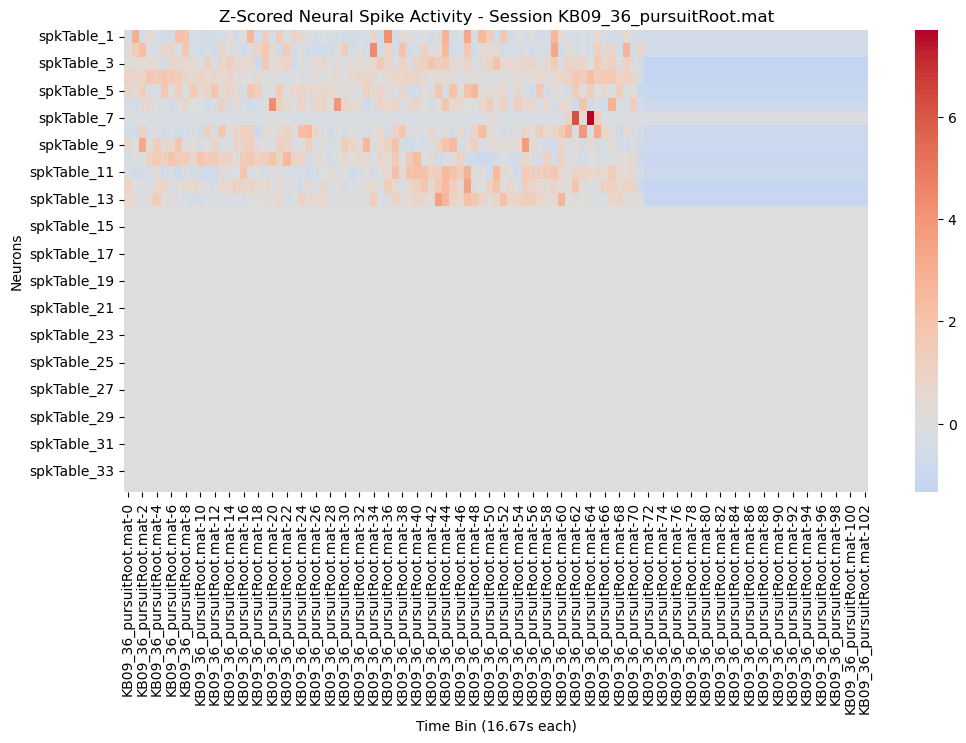

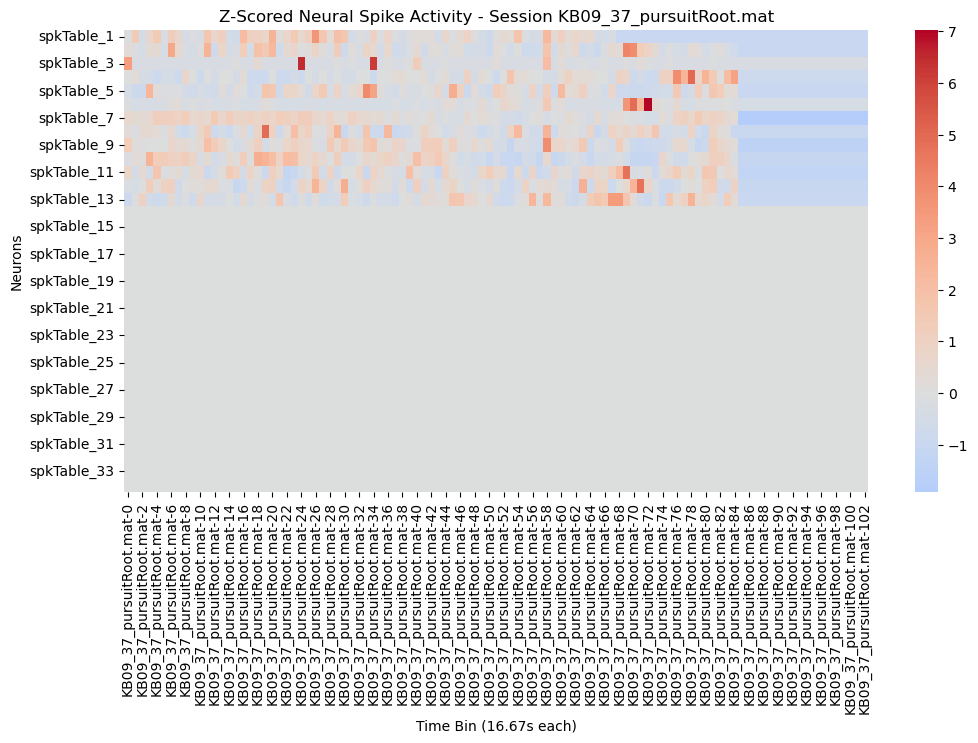

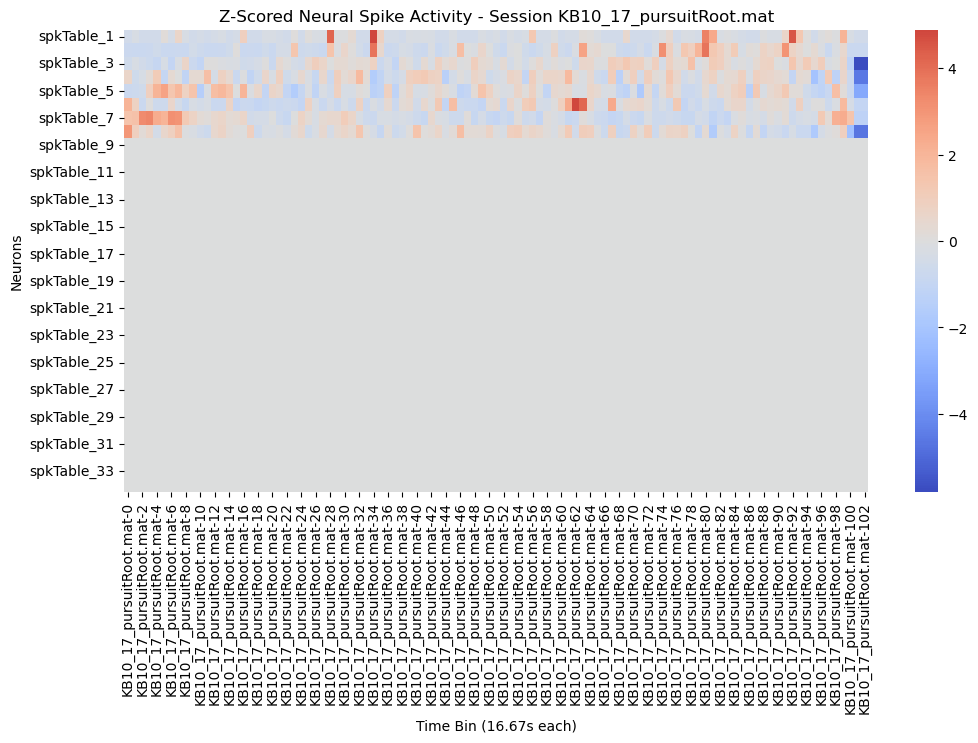

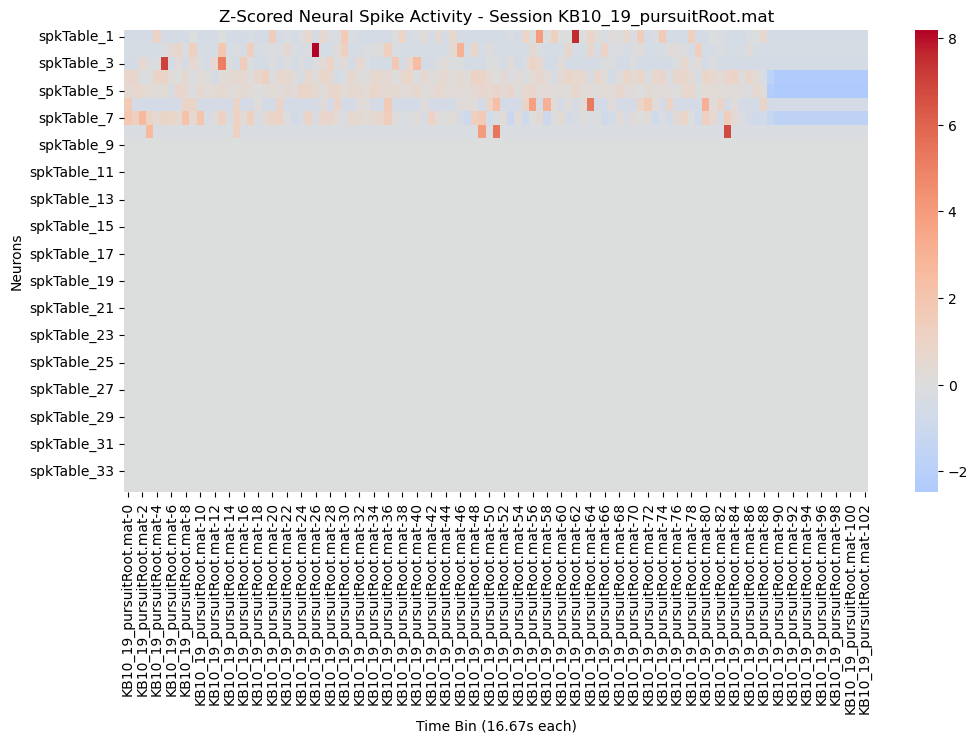

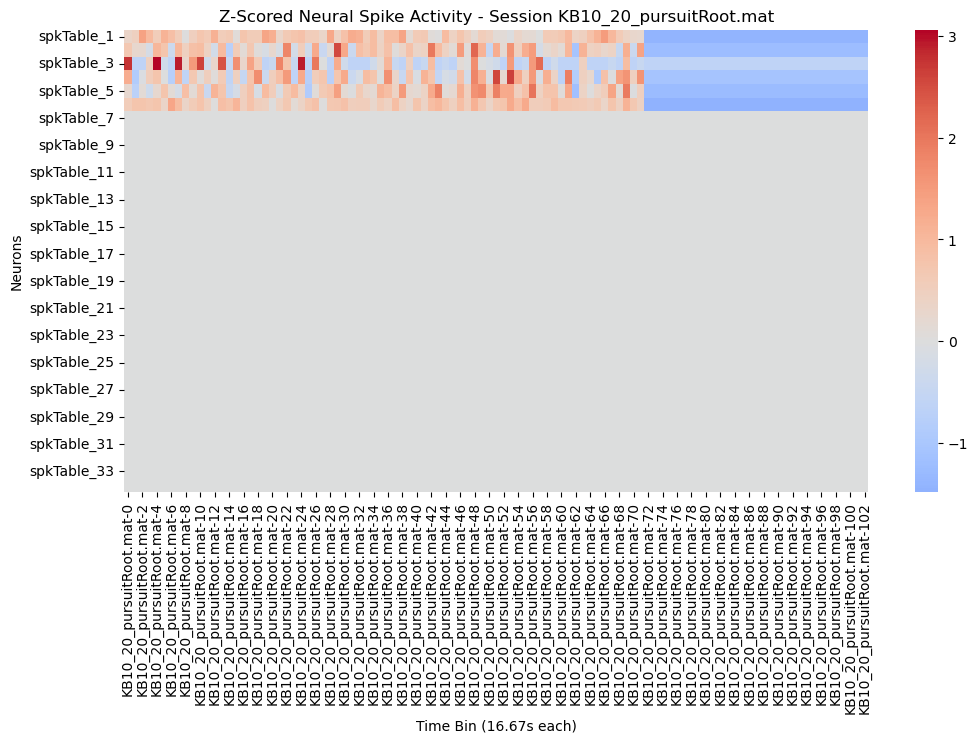

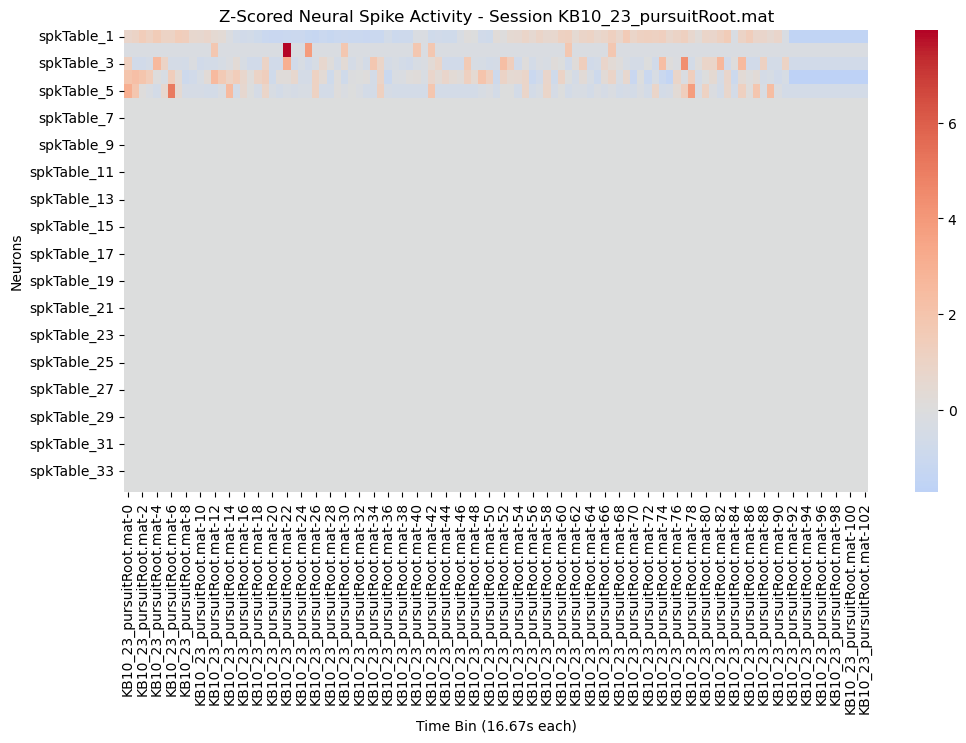

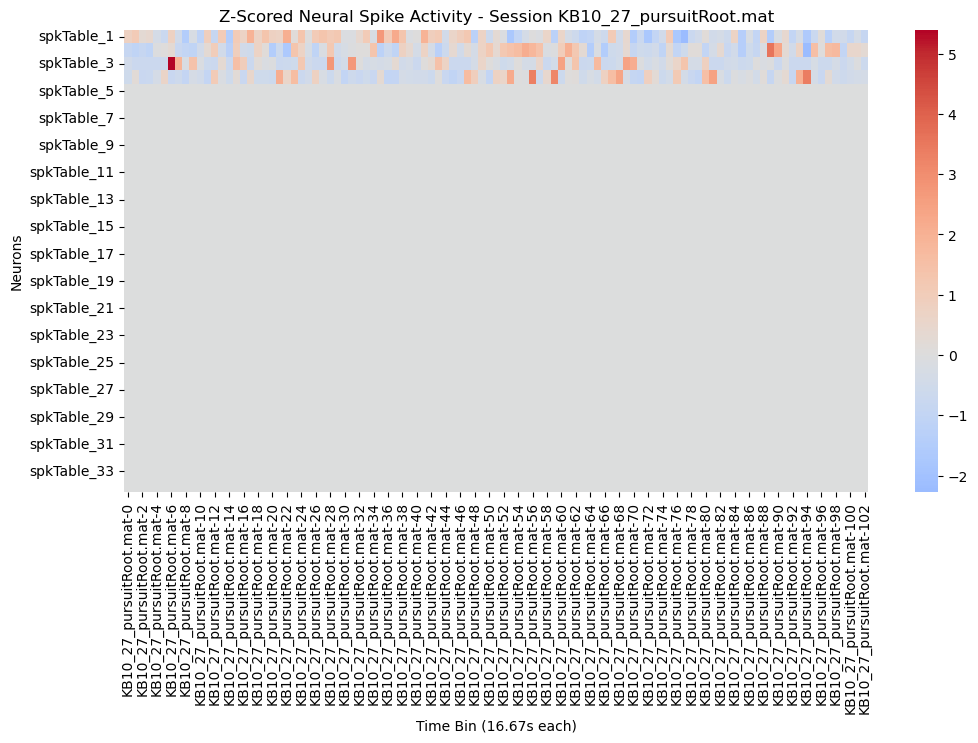

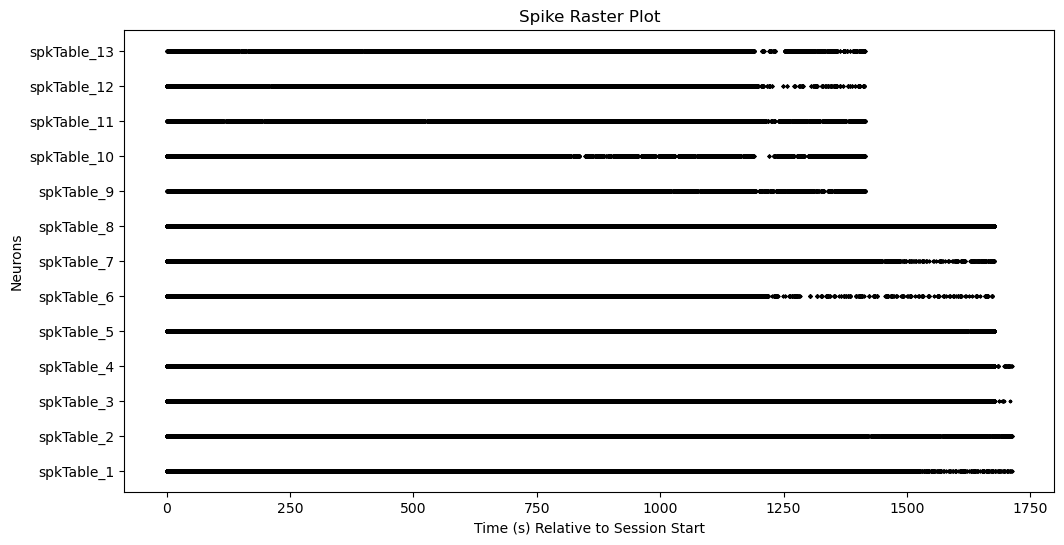

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

### 1️⃣ LOAD & FILTER YOUR DATA ###
# 🛠 EDIT: Ensure your dataset has the required columns
df = all_regions_data[(all_regions_data["region"] == "CA3") & (all_regions_data["trial_block"] == "pursuit")].copy()

# 🛠 EDIT: Ensure necessary columns exist
if "time" not in df.columns or "trial_block" not in df.columns or "region" not in df.columns:
    raise ValueError("Dataset must have 'time', 'trial_block', and 'region' columns!")

# 🛠 EDIT: Detect spike table columns automatically
spike_columns = [col for col in df.columns if "spkTable" in col]

### 2️⃣ NORMALIZE TIME PER SESSION ###
# Ensure sessFile is treated as a category to avoid issues
df["sessFile"] = df["sessFile"].astype("category")

# Compute start time per session and normalize time
df["time"] = df["time"].astype("float64")  # Convert time to float64
df["start_time"] = df.groupby("sessFile")["time"].transform("min")
df["normalized_time"] = df["time"] - df["start_time"]


# 🛠 EDIT: If time is in milliseconds, divide by 1000 before normalization
# df["normalized_time"] = (df["time"] / 1000) - df.groupby("sessFile")["time"].transform("min")

### 3️⃣ CREATE TIME BINS (16.67s) ###
bin_width = 16.67  # Time bin size in seconds
df["time_bin"] = (df["normalized_time"] // bin_width).astype(int)

### 4️⃣ AGGREGATE SPIKE COUNTS PER TIME BIN ###
# Convert spike data to integers, replacing NaNs with 0
df[spike_columns] = df[spike_columns].fillna(0).astype(int)

# Group by "sessFile" and "time_bin" to avoid mixing sessions
df_binned = df.groupby(["sessFile", "time_bin"])[spike_columns].sum()

### 5️⃣ APPLY Z-SCORE NORMALIZATION PER NEURON, PER SESSION ###
# Ensure z-score works even if variance is 0
df_zscored = df_binned.groupby("sessFile").apply(lambda x: x.apply(lambda col: zscore(col, nan_policy="omit") if col.std() > 0 else col, axis=0))

# Verify results
print(df_zscored.head())

### 6️⃣ PLOT HEATMAP FOR EACH SESSION ###
for session in df["sessFile"].unique():
    session_data = df_zscored.loc[session]  # Get session-specific data

    plt.figure(figsize=(12, 6))
    sns.heatmap(session_data.T, cmap="coolwarm", center=0, cbar=True)
    plt.xlabel("Time Bin (16.67s each)")
    plt.ylabel("Neurons")
    plt.title(f"Z-Scored Neural Spike Activity - Session {session}")
    plt.show()

### 7️⃣ OPTIONAL: RASTER PLOT (SPIKES OVER TIME) ###
plt.figure(figsize=(12, 6))

for neuron in spike_columns:
    neuron_data = df[df[neuron] > 0]  # Get rows where spikes occurred
    plt.scatter(neuron_data["normalized_time"], np.full(len(neuron_data), neuron), s=2, color="black")

plt.xlabel("Time (s) Relative to Session Start")
plt.ylabel("Neurons")
plt.title("Spike Raster Plot")
plt.show()


In [9]:
#define the start and end indices
pursuit_start = (indices["pursuit_start"].values[0])
pursuit_end = (indices["pursuit_end"].values[0])
FE1_start = (indices["FE1_start"].values[0])
FE1_end = (indices["FE1_end"].values[0])
FE2_start = (indices["FE2_start"].values[0])
FE2_end = (indices["FE2_end"].values[0])

#get dataframe length
max_rows = len(pursuit_df['KB20_09_pursuitRoot.mat'])

#call get_block_rows() before slicing
FE1_start, FE1_end = pursuit_functions.index_utils.get_block_rows(FE1_start, FE1_end, max_rows)
pursuit_start, pursuit_end = pursuit_functions.index_utils.get_block_rows(pursuit_start, pursuit_end, max_rows)
FE2_start, FE2_end = pursuit_functions.index_utils.get_block_rows(FE2_start, FE2_end, max_rows)

#slice the data rows into trial blocks (FE= free explore)
FE1_block = pursuit_df['KB20_09_pursuitRoot.mat'].iloc[FE1_start:FE1_end +1]if FE1_start is not None else None
pursuit_block = pursuit_df['KB20_09_pursuitRoot.mat'].iloc[pursuit_start:pursuit_end +1] if pursuit_start is not None else None
FE2_block = pursuit_df['KB20_09_pursuitRoot.mat'].iloc[FE2_start:FE2_end +1] if FE2_start is not None else None

print("\ncheck out the blocks")
print(pursuit_block)
print(FE1_block)
print(FE2_block)


check out the blocks
              time      ind    ratPos_1    ratPos_2  laserPos_1  laserPos_2  \
2803     46.734268   2804.0  139.363282  123.920803         NaN         NaN   
2804     46.750935   2805.0  139.511148  123.804249         NaN         NaN   
2805     46.767602   2806.0  139.667713  123.696394         NaN         NaN   
2806     46.784269   2807.0  139.824277  123.602455         NaN         NaN   
2807     46.800936   2808.0  139.980842  123.525912         NaN         NaN   
...            ...      ...         ...         ...         ...         ...   
98098  1635.016033  98099.0  149.985313   66.118929         NaN         NaN   
98099  1635.032700  98100.0  150.531549   65.680548         NaN         NaN   
98100  1635.049367  98101.0  151.067348   65.231730         NaN         NaN   
98101  1635.066034  98102.0  151.582271   64.786391         NaN         NaN   
98102  1635.082701  98103.0  152.083277   64.354969         NaN         NaN   

          ratVel     ratAcc  

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


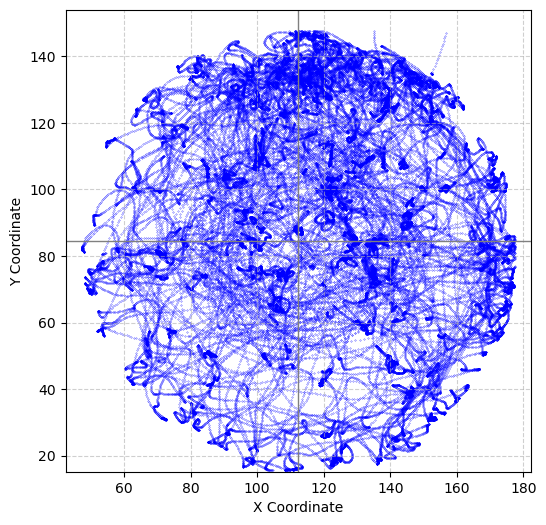

In [10]:
import matplotlib.pyplot as plt 

x = pursuit_block["ratPos_1"]
y = pursuit_block["ratPos_2"]

x_center = (x.max() + x.min()) / 2
y_center = (y.max() + y.min()) / 2

x_range = (x.max() - x.min()) / 2
y_range = (y.max() - y.min()) / 2
limit = max(x_range, y_range)  # Use max range to keep aspect equal

fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(x, y, c='blue', label="Points", s=0.05)

ax.set_xlim([x_center - limit, x_center + limit])
ax.set_ylim([y_center -limit, y_center +limit])

ax.set_aspect('equal', adjustable='datalim')

ax.axhline(y_center, color="gray", linewidth=1)
ax.axvline(x_center, color="gray", linewidth=1)
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")



plt.show()